# 📈 Notebook 04: Validación con Datos Reales (IGE)
**Objetivo:** Comparar los perfiles obtenidos mediante IA con la población real de ames (2025) para medir el impacto potencial de la parroquia.

---

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 1. Configuración de Rutas
BASE_DIR = Path.cwd().parent
# El que guardamos en el Notebook 03
PATH_RESULTADOS_IA = BASE_DIR / "data" / "processed" / "resultados_ia_jovenes.csv"
# Los de IGE
PATH_IGE_ANUAL = BASE_DIR / "data" / "processed" / "jovenes_18_35_por_año.csv"
PATH_IGE_DETALLE =BASE_DIR / "data" / "processed" / "poblacion_jovenes_ames.csv"

# 2. Carga de DataFrames
df_ia = pd.read_csv(PATH_RESULTADOS_IA)
df_tendencia = pd.read_csv(PATH_IGE_ANUAL)
df_poblacion = pd.read_csv(PATH_IGE_DETALLE)

print("✅ Todo cargado correctamente:")
print(f"Encuestados: {len(df_ia)} | Datos IGE hasta año: {df_tendencia["ano"].max()}")

✅ Todo cargado correctamente:
Encuestados: 15 | Datos IGE hasta año: 2025


## 1. Evolución Demográfica en Ames
¿Está creciendo el público objetivo de la parroquia? Analizamos la tendencia de los últimos 5 años.

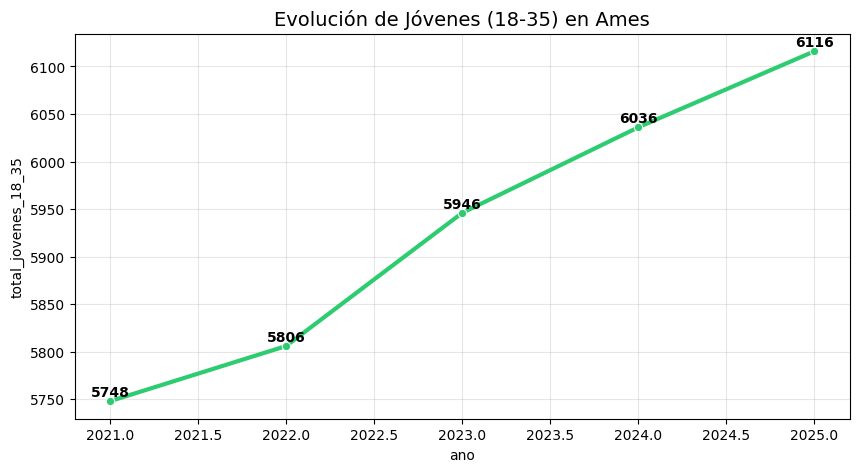

In [30]:
plt.figure(figsize=(10,5))
sns.lineplot(data=df_tendencia, x="ano", y="total_jovenes_18_35", marker="o", color="#2ecc71", linewidth=3)

# Añadir los números encima de los puntos
for x, y in zip(df_tendencia["ano"], df_tendencia["total_jovenes_18_35"]):
    plt.text(x, y + 5, f"{y}", ha="center", fontweight="bold")

plt.title("Evolución de Jóvenes (18-35) en Ames", fontsize=14)
plt.grid(True, alpha=0.3)
plt.savefig(FIGURES_DIR / "07_evolucion_jovenes_ames.png", dpi=300)
plt.show()

## 2. Radiografía del Universo Joven (2025)
Calculamos cuántos Gen Z y Millennials hay realmente en el municipio para compararlos con nuestra muestra.


In [32]:
# Filtramos el año más reciente 
df_2025 = df_poblacion[df_poblacion["ano"] == 2025]

# Cálculo de Totales Reales
total_gen_z_real = df_2025[(df_2025["edad"] >= 18) & (df_2025["edad"] <= 25)]["poblacion"].sum()
total_millennials_real = df_2025[(df_2025["edad"] >=26) & (df_2025["edad"] <= 35)]["poblacion"].sum()
total_universo = total_gen_z_real + total_millennials_real

# Cálculo de nuestra Encuesta
total_gen_z_encuesta = len(df_ia[df_ia["edad"] <= 25])
total_millennials_encuesta = len(df_ia[df_ia["edad"] > 25])
total_muestra = total_gen_z_encuesta + total_millennials_encuesta

print(f"🌍 Universo Real (IGE): {int(total_universo)} jóvenes.")
print(f"📋 Nuestra Muestra: {total_muestra} jóvenes")

🌍 Universo Real (IGE): 6116 jóvenes.
📋 Nuestra Muestra: 15 jóvenes


## 3. Comparativa de Represantatividad
¿A qué grupo estamos llegando mejor y a cuál estamos ignorando?

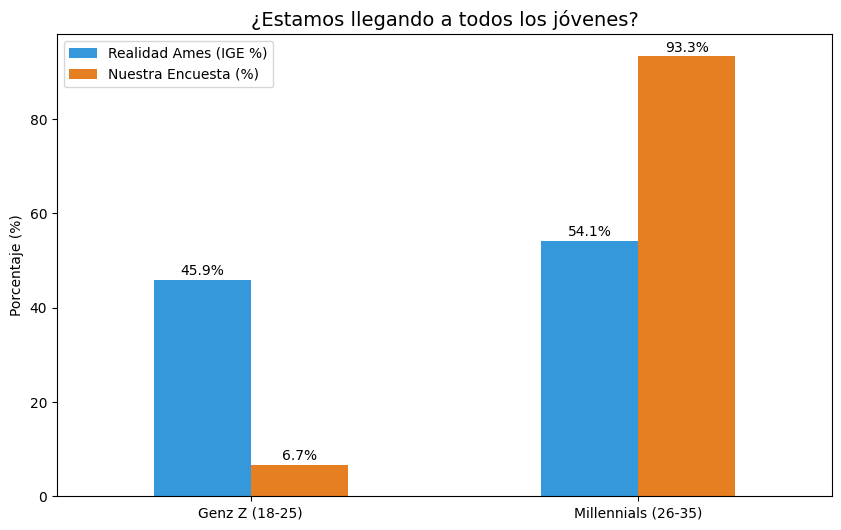

In [33]:
# Creamos el DataFrame comparativo en %
comparativa = pd.DataFrame({
    "Realidad Ames (IGE %)": [total_gen_z_real / total_universo * 100, total_millennials_real / total_universo * 100],
    "Nuestra Encuesta (%)": [total_gen_z_encuesta / total_muestra * 100, total_millennials_encuesta / total_muestra * 100]
}, index=["Genz Z (18-25)", "Millennials (26-35)"])

# Gráfico de barras
ax = comparativa.plot(kind="bar", figsize=(10,6), color=["#3498db", "#e67e22"])
plt.title("¿Estamos llegando a todos los jóvenes?", fontsize=14)
plt.ylabel("Porcentaje (%)")
plt.xticks(rotation=0)

# añadir etiquetas de porcentaje
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 1), ha="center")

plt.savefig(FIGURES_DIR / "09_comparativa_ige_encuesta.png", dpi=300)
plt.show()

## 🎯 Conclusión Final: La Brecha de Oportunidad
Este útimo gráfico es el más revelador de todo el análisis. al comparar nuestra **Muestra (Encuesta)** con el **Universo Real (IGE 2025)**, extraemos tres conclusiones estratégicas:

1. **El "Gap" de la Gen Z:** Mientras que en Ames los jóvenes de 18-25 años representan casi el **46%** de la juventud, en nuestra encuesta están infrarepresentados. Esto indica que los métodos de comunicación actuales de la parroquia no están resonando con los más jóvenes.
2. **Dominio Millennial:** Tenemos una línea directa con los mayores de 26 años. Ellos son quienes están contestando y quienes forman el "núcleo" actual, pero corremos el riego de convertirnos en una comunidad que no se renueva si no cerramos la brecha anterior.
3. **Potencial de Crecimiento:** Con **6.116 jóvenes** en el municipio y una muestra de 15, cada respuesta positiva en nuestra encuesta representa a cientos de jóvenes en la vida real que probablemente tienen las mismas necesidades (Deporte, Espiritualidad Moderna, Eventos Sociales).

---

### 💡 Recomendaciones Maestra
Para alcanzar ese **46% de Gen Z** que el IGE nos dice que existe, el **Cluster 2 (Deporte/Excursiones)** es nuestra mejor herramienta. Es un lenguaje universal que rompe la barrera de la "religiosidad formal" y permite una primera toma de contacto con la parroquia.

**fin del Análisis Técnico.**
*Datos actualizados a Abril 2026.*